# Patnaik-Pearson meets BERT internal representations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd
import random

import torch

In [ ]:
!pip install cupy-cuda12x

In [2]:
import PatnaikPearson as pp
import cupy

In [3]:
!nvidia-smi

Sat Jun 13 20:32:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.79                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 2000 Ada Gene...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   30C    P8              2W /   40W |       0MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# !pip install transformers
#!pip install transformers accelerate
#!pip install transformers==4.51.3
!pip install transformers==4.44.0 accelerate==0.33.0

In [4]:
# new - disable SDPA (Scaled Dot Product Attention)

from transformers import BertModel, BertConfig, BertTokenizer

# Load model with SDPA disabled
model = BertModel.from_pretrained(
    'bert-base-uncased',
    output_hidden_states=True,
    attn_implementation='eager'   # disables SDPA, uses classic attention
)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model.eval()

C:\Users\Dell\OneDrive\Documents\TomDocuments\PythonProjects\PP\20260527\PatnaikPearson\ml_env311_v2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name tha

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [5]:
import transformers
print(transformers.__version__)
print(transformers.__file__)

4.44.0
C:\Users\Dell\OneDrive\Documents\TomDocuments\PythonProjects\PP\20260527\PatnaikPearson\ml_env311_v2\Lib\site-packages\transformers\__init__.py


In [6]:
import torch
print(torch.__version__)

2.5.1+cu121


In [7]:
from transformers import BertModel, BertConfig
print("import OK")

import OK


# PP dim of token embeddings

In [8]:
valid_embeddings, invalid_embeddings = pp.get_valid_invalid_bert_base_token_embeddings(model)

In [9]:
print(valid_embeddings.shape)
print(invalid_embeddings.shape)

(29528, 768)
(994, 768)


In [6]:
pp_dim_inv_emb = pp.calculate_PatnaikPearson_dim(invalid_embeddings, verbose=False)
print("pp_dim_inv_emb = ", pp_dim_inv_emb)

pp_dim_inv_emb =  561.742428250816


In [17]:
# Apply the function using np.vectorize
this_vec_sqrt = np.vectorize(math.sqrt)

In [54]:
analyse_embeddings(invalid_embeddings)

print("\n===============================\n")

analyse_embeddings(valid_embeddings)

average initial norm =  1.1608907419616068
std initial norm =  0.0010624252440962622
avg.shape =  (768,)
norm(avg) =  1.1541711242005153
norm(avg_normalised) =  1.0
these_betas.shape =  (994,)
[0.98802714 0.98946532 0.9883126  0.98830278 0.98807439]
average resid norm =  0.12541312866072366
std resid norm =  0.0031445261752445887


average initial norm =  1.4095106098657946
std initial norm =  0.191249034702401
avg.shape =  (768,)
norm(avg) =  0.9373921515531835
norm(avg_normalised) =  0.9999999999999999
these_betas.shape =  (29528,)
[0.7030876  0.36125774 0.05777034 0.09988147 0.08914333]
average resid norm =  1.1757898007534908
std resid norm =  0.19216714080377892


In [51]:
def analyse_embeddings(X : np.ndarray, calc_pp_dim : bool = False):
    # X is N * d
    if calc_pp_dim:
        pp_dim_X = pp.calculate_PatnaikPearson_dim(X)
        print("pp_dim_X = ", pp_dim_X)
    num_embeddings = X.shape[0]
    these_norms = np.zeros(num_embeddings)
    for i in range(num_embeddings):
        xi = X[i,:]
        these_norms[i] = np.sqrt(np.dot(xi,xi))
    print("average initial norm = ", np.mean(these_norms))
    print("std initial norm = ", np.std(these_norms))

    avg = np.mean(X, axis=0)
    print("avg.shape = ", avg.shape)
    print("norm(avg) = ", math.sqrt(np.dot(avg,avg)))

    avg_normalised = avg / math.sqrt(np.dot(avg,avg))
    print("norm(avg_normalised) = ",math.sqrt(np.dot(avg_normalised,avg_normalised)))

    these_betas = np.zeros(num_embeddings) #(X @ avg_normalised) / these_norms_sqrd
    X_resid = np.zeros(X.shape)
    for i in range(num_embeddings):
        xi = X[i,:]
        this_beta = np.dot(xi, avg) / these_norms[i]**2
        these_betas[i] = this_beta
        X_resid[i,:] = xi - this_beta * avg
    print("these_betas.shape = ", these_betas.shape)
    k=5
    print(these_betas[0:k])

    these_resid_norms = np.zeros(num_embeddings)
    for i in range(num_embeddings):
        xri = X_resid[i,:]
        these_resid_norms[i] = np.sqrt(np.dot(xri,xri))
    print("average resid norm = ", np.mean(these_resid_norms))
    print("std resid norm = ", np.std(these_resid_norms))

    

In [34]:
pp_dim_inv_emb = pp.calculate_PatnaikPearson_dim(invalid_embeddings)
print("pp_dim_inv_emb = ", pp_dim_inv_emb)

pairwise_dot_products = invalid_embeddings @ invalid_embeddings.T
these_norms_sqrd = np.diag(pairwise_dot_products)
these_norms = this_vec_sqrt(these_norms_sqrd)
print("np.mean(these_norms) = ", np.mean(these_norms))
print("np.std(these_norms) = ", np.std(these_norms))

avg = np.mean(invalid_embeddings, axis=0)
print("avg.shape = ", avg.shape)

print("norm(avg) = ", math.sqrt(np.dot(avg,avg)))
#print(math.norm(avg))

avg_normalised = avg / math.sqrt(np.dot(avg,avg))
print("norm(avg_normalised) = ",math.sqrt(np.dot(avg_normalised,avg_normalised)))

these_betas = (invalid_embeddings @ avg_normalised) / these_norms_sqrd
print("these_betas.shape = ", these_betas.shape)
k=5
print(these_betas[0:k])

demeaned = invalid_embeddings - np.outer(these_betas,avg_normalised)
print(demeaned.shape)
print("sanity check = ", np.sum(demeaned @ avg_normalised))

dsqrd = demeaned @ demeaned.T
print(dsqrd.shape)
dsqrd_diag = np.diag(dsqrd)
norm_dsqrd_diag = this_vec_sqrt(dsqrd_diag)
print(norm_dsqrd_diag.shape)
print("np.mean(norm_dsqrd_diag) = ", np.mean(norm_dsqrd_diag))
print("np.std(norm_dsqrd_diag) = ", np.std(norm_dsqrd_diag))

pp_dim_demeaned = pp.calculate_PatnaikPearson_dim(demeaned)
print("pp_dim_demeaned = ", pp_dim_demeaned)

pp_dim_inv_emb =  561.742428250816
np.mean(these_norms) =  1.1608907419616068
np.std(these_norms) =  0.001062425244096265
avg.shape =  (768,)
norm(avg) =  1.1541711242005153
norm(avg_normalised) =  1.0
these_betas.shape =  (994,)
[0.85604909 0.85729516 0.85629642 0.85628791 0.85609003]
(994, 768)
sanity check =  295.96236691801175
(994, 994)
(994,)
np.mean(norm_dsqrd_diag) =  0.3228136199787423
np.std(norm_dsqrd_diag) =  0.002346903839143257
pp_dim_demeaned =  561.8426922262768


shape : (29528, 768)
min : -0.9503687620162964
max : 0.8728917837142944
sum : -640121.8116992312
mean : -0.028227172254020157
std : 0.04286872059736508


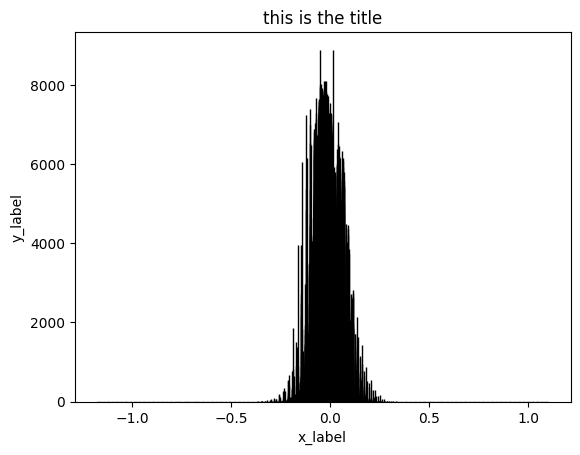

In [9]:
pp.display_stats(valid_embeddings)
pp.plot_histogram(valid_embeddings)

In [11]:
  avg_embedding = np.mean(valid_embeddings, axis=0)
  print("norm(avg_embedding) :", math.sqrt(np.dot(avg_embedding,avg_embedding)))

  # demean:
  demeaned_valid_embeddings = valid_embeddings - avg_embedding
  sanity_check = np.mean(demeaned_valid_embeddings, axis=0)
  print("sanity check - should be zero : ", np.dot(sanity_check,sanity_check))

norm(avg_embedding) : 0.9373921515531835
sanity check - should be zero :  2.0140286166514216e-27


In [18]:
pp.display_stats(demeaned_valid_embeddings)

shape : (29528, 768)
min : -0.965803914380531
max : 0.8108774947924399
sum : 0.0
mean : 0.0
std : 0.03860511062220628


In [16]:
this_mean = -0.028227172254020157
this_std = 0.04286872059736508
#this_std = 
random_embeddings = np.random.normal(this_mean, this_std, valid_embeddings.shape)
print(random_embeddings.shape)
avg_embedding = np.mean(random_embeddings, axis=0)
print("norm(avg_embedding) :", math.sqrt(np.dot(avg_embedding,avg_embedding)))

(29528, 768)
norm(avg_embedding) : 0.7822535640392416


In [72]:
xx = sample_pp_dim(valid_embeddings, 512, 10)

num_embeddings =  29528
embedding_dim =  768
random_indices.shape =  (512,)
0 pp_dim_X0 =  373.7414886876876
0 nu_over_d_X0 =  0.48664256339542655
random_indices.shape =  (512,)
1 pp_dim_X0 =  377.3393645843414
1 nu_over_d_X0 =  0.4913272976358612
random_indices.shape =  (512,)
2 pp_dim_X0 =  377.46562745770353
2 nu_over_d_X0 =  0.4914917024188848
random_indices.shape =  (512,)
3 pp_dim_X0 =  372.6611172827507
3 nu_over_d_X0 =  0.4852358297952483
random_indices.shape =  (512,)
4 pp_dim_X0 =  375.8269275420423
4 nu_over_d_X0 =  0.4893579785703676
random_indices.shape =  (512,)
5 pp_dim_X0 =  373.0283444120825
5 nu_over_d_X0 =  0.4857139901198991
random_indices.shape =  (512,)
6 pp_dim_X0 =  373.3146390483223
6 nu_over_d_X0 =  0.4860867695941697
random_indices.shape =  (512,)
7 pp_dim_X0 =  374.9408441190735
7 nu_over_d_X0 =  0.488204224113377
random_indices.shape =  (512,)
8 pp_dim_X0 =  375.40019300648436
8 nu_over_d_X0 =  0.48880233464385986
random_indices.shape =  (512,)
9 pp_dim_X0 

In [73]:
these_num_samples = np.array([100,200,300,400,512,650,768,1000,1500,2000,2500,3000,4000,5000,7500,10000])

these_pp_dim_mean_vals = np.zeros(len(these_num_samples))
these_pp_dim_std_vals = np.zeros(len(these_num_samples))
these_nu_over_d_mean_vals = np.zeros(len(these_num_samples))
these_nu_over_d_std_vals = np.zeros(len(these_num_samples))

i = 0
for num_samples in these_num_samples:
    num_iterations = 5
    if num_samples < 3000: 
        num_iterations = 10
    if num_samples < 1000:
        num_iterations = 20
    xx = sample_pp_dim(valid_embeddings, num_samples, num_iterations)

    pp_dim_X0_vals = xx["pp_dim_X0_vals"]
    pp_dim_X0_mean = np.mean(pp_dim_X0_vals)
    pp_dim_X0_std = np.std(pp_dim_X0_vals)
    these_pp_dim_mean_vals[i] = pp_dim_X0_mean 
    these_pp_dim_std_vals[i] = pp_dim_X0_std 
    print(i, pp_dim_X0_mean, pp_dim_X0_std)

    nu_over_d_X0_vals = xx["nu_over_d_X0_vals"]
    nu_over_d_X0_mean = np.mean(nu_over_d_X0_vals)
    nu_over_d_X0_std = np.std(nu_over_d_X0_vals)
    these_nu_over_d_mean_vals[i] = nu_over_d_X0_mean 
    these_nu_over_d_std_vals[i] = nu_over_d_X0_std 
    print(i, nu_over_d_X0_mean, nu_over_d_X0_std)

    i += 1
    
    
        
        


num_embeddings =  29528
embedding_dim =  768
random_indices.shape =  (100,)
0 pp_dim_X0 =  90.36847437377709
0 nu_over_d_X0 =  0.11766728434085559
random_indices.shape =  (100,)
1 pp_dim_X0 =  89.6143389902466
1 nu_over_d_X0 =  0.11668533722688358
random_indices.shape =  (100,)
2 pp_dim_X0 =  89.64897149760507
2 nu_over_d_X0 =  0.11673043163750661
random_indices.shape =  (100,)
3 pp_dim_X0 =  91.17803365361986
3 nu_over_d_X0 =  0.11872139798648419
random_indices.shape =  (100,)
4 pp_dim_X0 =  90.70177217744269
4 nu_over_d_X0 =  0.11810126585604518
random_indices.shape =  (100,)
5 pp_dim_X0 =  90.70260431251441
5 nu_over_d_X0 =  0.11810234936525314
random_indices.shape =  (100,)
6 pp_dim_X0 =  90.34711063947375
6 nu_over_d_X0 =  0.11763946697848145
random_indices.shape =  (100,)
7 pp_dim_X0 =  90.00706277349128
7 nu_over_d_X0 =  0.11719669631965011
random_indices.shape =  (100,)
8 pp_dim_X0 =  89.85031014650744
8 nu_over_d_X0 =  0.11699259133659823
random_indices.shape =  (100,)
9 pp_di

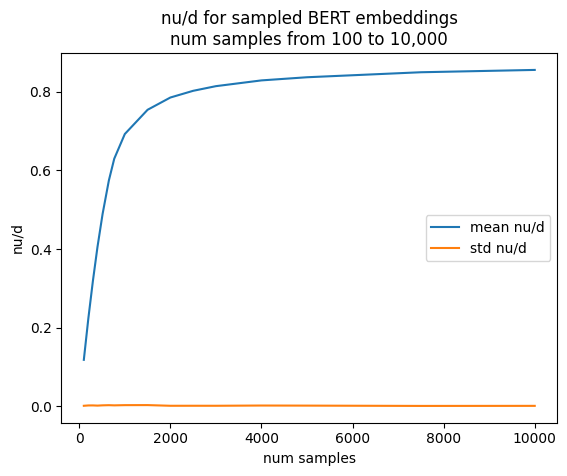

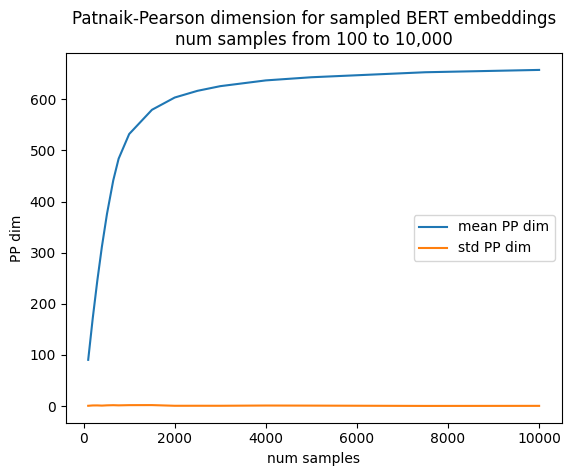

In [84]:
this_title = "nu/d for sampled BERT embeddings\n"
this_title += "num samples from 100 to 10,000"
plt.plot(these_num_samples, these_nu_over_d_mean_vals, label = "mean nu/d")
plt.plot(these_num_samples, these_nu_over_d_std_vals, label = "std nu/d")
plt.xlabel("num samples")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
#plt.savefig('nu_over_d_for_sampled_BERT_embeddings.pdf', dpi=300, bbox_inches='tight')
plt.show()

this_title = "Patnaik-Pearson dimension for sampled BERT embeddings\n"
this_title += "num samples from 100 to 10,000"
plt.plot(these_num_samples, these_pp_dim_mean_vals, label = "mean PP dim")
plt.plot(these_num_samples, these_pp_dim_std_vals, label = "std PP dim")
plt.xlabel("num samples")
plt.ylabel("PP dim")
plt.legend()
plt.title(this_title)
plt.savefig('pp_dim_for_sampled_BERT_embeddings.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [70]:
def sample_pp_dim(X : np.ndarray, num_samples : int, num_iterations : int) -> tuple:
    num_embeddings, embedding_dim = X.shape
    print("num_embeddings = ", num_embeddings)
    print("embedding_dim = ", embedding_dim)
    num_samples = min(num_samples, num_embeddings)

    pp_dim_X0_vals = np.zeros(num_iterations)
    nu_over_d_X0_vals = np.zeros(num_iterations)
    for k in range(num_iterations):
        random_indices = np.random.choice(num_embeddings, num_samples, replace = False)
        print("random_indices.shape = ", random_indices.shape)
        X0 = np.zeros((num_samples,embedding_dim))
        for i in range(num_samples):
              this_index = random_indices[i]
              X0[i,:] = X[this_index]
        pp_dim_X0 = pp.calculate_PatnaikPearson_dim(X0, verbose=False)
        dim_X0 = X0.shape[1]
        nu_over_d_X0 = pp_dim_X0 / dim_X0
        print(k, "pp_dim_X0 = ", pp_dim_X0)
        print(k, "nu_over_d_X0 = ", nu_over_d_X0)
        pp_dim_X0_vals[k] = pp_dim_X0
        nu_over_d_X0_vals[k] = nu_over_d_X0

    results_dict = {
        "pp_dim_X0_vals" : pp_dim_X0_vals,
        "nu_over_d_X0_vals" : nu_over_d_X0_vals
    }

    return results_dict
        
    

In [7]:
num_embeddings = 2000
num_valid_embeddings = valid_embeddings.shape[0] #len(valid_ids)
print("num_valid_embeddings =", num_valid_embeddings)
num_embeddings = min(num_embeddings, num_valid_embeddings)
print("num_embeddings =", num_embeddings)
embedding_dim = valid_embeddings.shape[1]
print("embedding_dim =", embedding_dim)

random_indices = np.random.choice(num_valid_embeddings, num_embeddings, replace = False)
print(random_indices.shape)

X = np.zeros((num_embeddings,768))
for i in range(num_embeddings):
  this_index = random_indices[i]
  X[i,:] = valid_embeddings[this_index]

print("X.shape = ", X.shape)

pp_dim_X = pp.calculate_PatnaikPearson_dim(X, verbose=False)
dim_X = X.shape[1]
nu_over_d_X = pp_dim_X / dim_X
print("pp_dim_X = ", pp_dim_X)
print("nu_over_d_X = ", nu_over_d_X)


num_valid_embeddings = 29528
num_embeddings = 2000
embedding_dim = 768
(2000,)
X.shape =  (2000, 768)
pp_dim_X =  600.9224614488321
nu_over_d_X =  0.7824511216781668


In [8]:
pp.analyse_embeddings(valid_embeddings)

these_embeddings.shape =  (29528, 768)
num_embeddings =  29528
raw embedding norm stats:
shape : (29528,)
min : 0.7657115047329871
max : 2.0445971930627644
sum : 41620.029288117184
mean : 1.4095106098657946
std : 0.191249034702401
norm : 244.42564247545445
norm(avg_embedding) : 0.9373921515531835
sanity check - should be zero :  2.0140286166514216e-27
raw demeaned_embedding norm stats:
shape : (29528,)
min : 0.5759314096862294
max : 2.1275616389432797
sum : 31302.248908141053
mean : 1.0600869990565245
std : 0.14424930237845343
norm : 183.84102272166575
num_iterations =  14
0 pp_dim_initial =  600.3859475766902
0 pp_dim_demeaned =  600.3859475766899
1 pp_dim_initial =  603.4586177397009
1 pp_dim_demeaned =  603.458617739701
2 pp_dim_initial =  602.9091566769871
2 pp_dim_demeaned =  602.9091566769875
3 pp_dim_initial =  603.2694426648897
3 pp_dim_demeaned =  603.2694426648894
4 pp_dim_initial =  604.9732531962665
4 pp_dim_demeaned =  604.9732531962667
5 pp_dim_initial =  602.212142203262

In [10]:
valid_bert_base_token_ids = pp.get_valid_bert_base_token_ids()
print(len(valid_bert_base_token_ids))

29528


In [21]:
num_samples = 1000
sampled_token_ids = np.random.choice(valid_bert_base_token_ids, size=num_samples, replace=False)
print(type(sampled_token_ids))
print(sampled_token_ids.shape)

sampled_token_ids_list = sampled_token_ids.tolist()
print(type(sampled_token_ids_list))

X0 = tokenizer.convert_ids_to_tokens(sampled_token_ids_list) 
print(type(X0))
print(X0[0:5])

<class 'numpy.ndarray'>
(1000,)
<class 'list'>
<class 'list'>
['thessaloniki', '##hr', 'calcutta', 'gujarati', 'agitated']


In [23]:
N = len(X0)
print("N = ", N)

# Build input: shape (1, N) — single "sentence" of N tokens
input_ids      = (torch.tensor(sampled_token_ids)).unsqueeze(0).to(DEVICE)          # (1, N)
attention_mask = torch.ones(1, N, dtype=torch.long).to(DEVICE)     # no padding


N =  1000


NameError: name 'DEVICE' is not defined